In [1]:
import sys
sys.path.append('../src')

In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf
from stock_prices import get_stock_prices, plot_stock_prices, split_train_test
from feature_extraction import add_state_column
from technical_indicator_classifier import TechnicalIndicatorClassifier
from hybrid_model import HybridModel
from simulation import simulate_trade

In [3]:
def check_stock_criteria(close_prices, drawdown_threshold = 0.5, runup_threshold = 1):
    """
    Returns True if stock satisfies regime constraints.
    
    Conditions:
    - Maximum drawdown < max_drawdown_thresh
    - Maximum run-up < max_runup_thresh
    """

    prices = close_prices.values

    # Compute rolling max
    rolling_max = np.maximum.accumulate(prices)
    drawdowns = (prices - rolling_max) / rolling_max
    max_drawdown = abs(drawdowns.min())

    # Compute rolling min
    rolling_min = np.minimum.accumulate(prices)
    runups = (prices - rolling_min) / rolling_min
    max_runup = runups.max()

    print(max_drawdown)
    print(max_runup)

    if max_drawdown > drawdown_threshold:
        return False
    
    if max_runup > runup_threshold:
        return False

    return True

def check_tradeable(prices, min_mean_return = 0.005, max_flat_ratio = 0.4, max_spike = 0.25):

    prices = np.array(prices)
    returns = np.abs(np.diff(prices) / prices[:-1])

    mean_return = np.mean(returns)

    flat_ratio = np.mean(returns < 0.002)

    spike = np.max(returns)

    return (
        mean_return >= min_mean_return and
        flat_ratio <= max_flat_ratio and
        spike <= max_spike
    )

def check_volatility(prices, min_vol = 0.10, max_vol = 0.50):
    returns = np.diff(np.log(prices))
    vol = np.std(returns) * np.sqrt(len(returns))
    print(vol)
    return min_vol <= vol <= max_vol

In [76]:
symbol = "KLBF.JK"
start_date = "2023-01-01"
split_date = "2024-12-31"
end_date = "2025-12-31"

$KLBF.JK: possibly delisted; no price data found  (1d 2023-01-01 -> 2023-01-02)


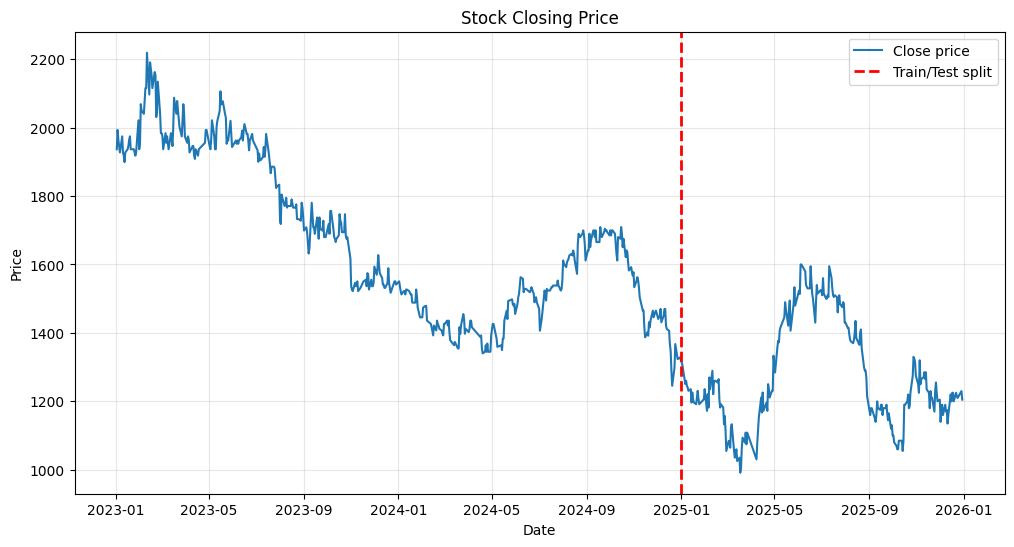

In [77]:
stock_prices = get_stock_prices(symbol, start_date, end_date)
plot_stock_prices(stock_prices, split_date)
stock_prices.head()
add_state_column(stock_prices)
stock_prices_train, stock_prices_test = split_train_test(stock_prices, split_date)

In [78]:
print(check_stock_criteria(stock_prices_train["close"]))
print(check_tradeable(stock_prices_train["close"]))
print(check_volatility(stock_prices_train["close"]))

0.4387064988652775
0.2755101390186895
True
True
0.3961651136797781
True
